# 🏦 BNPL (Buy Now Pay Later) — Default Risk Analysis
### End-to-End ML Pipeline | EDA → SMOTE → Models → Clustering → TOPSIS
---
**Dataset:** 40,000 BNPL loan records | **Target:**  (0 = Safe, 1 = Risky)

This notebook covers:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing & SMOTE Oversampling
3. Model Training (Logistic Regression + Random Forest)
4. KMeans Customer Segmentation
5. TOPSIS Multi-Criteria Risk Scoring
6. Model Saving for Streamlit Deployment
---

## 📦 1. Install Dependencies

In [5]:
!pip install -q imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

## 📂 2. Load Dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Load data ──────────────────────────────────────────────────
df = pd.read_csv('bnpl_sample_40000 (2).csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (40000, 18)
Columns: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,C671N8KVAG,39,142253,101017,604,12,4,20.84,48,0.87,PhD,Part-time,Single,Yes,Yes,Education,No,0
1,1L1ATEHC1P,49,16444,41479,564,50,4,8.37,36,0.28,PhD,Part-time,Married,No,Yes,Home,Yes,0
2,WO8D7VBUAD,40,38777,127506,456,119,1,21.20,12,0.10,High School,Full-time,Married,No,Yes,Auto,Yes,0
3,K6WNKGWR0M,42,82100,170466,767,106,3,10.54,60,0.11,PhD,Unemployed,Divorced,Yes,Yes,Education,Yes,0
4,9Q96VZFFU0,63,148159,6895,564,11,4,6.03,48,0.19,High School,Part-time,Single,No,No,Home,Yes,0


## 🔍 3. Data Quality Check

In [7]:
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LoanID          40000 non-null  object 
 1   Age             40000 non-null  int64  
 2   Income          40000 non-null  int64  
 3   LoanAmount      40000 non-null  int64  
 4   CreditScore     40000 non-null  int64  
 5   MonthsEmployed  40000 non-null  int64  
 6   NumCreditLines  40000 non-null  int64  
 7   InterestRate    40000 non-null  float64
 8   LoanTerm        40000 non-null  int64  
 9   DTIRatio        40000 non-null  float64
 10  Education       40000 non-null  object 
 11  EmploymentType  40000 non-null  object 
 12  MaritalStatus   40000 non-null  object 
 13  HasMortgage     40000 non-null  object 
 14  HasDependents   40000 non-null  object 
 15  LoanPurpose     40000 non-null  object 
 16  HasCoSigner     40000 non-null  object 
 17  Default   

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,43.61,82291.99,127785.87,574.77,59.37,2.50,13.56,36.06,0.50,0.12
std,14.97,39028.64,71078.05,158.88,34.56,1.12,6.63,16.94,0.23,0.32
min,18.00,15011.00,5000.00,300.00,0.00,1.00,2.00,12.00,0.10,0.00
25%,31.00,48488.75,65917.25,437.00,30.00,2.00,7.84,24.00,0.30,0.00
50%,44.00,82042.00,127617.00,575.00,59.00,2.00,13.57,36.00,0.50,0.00
75%,57.00,116031.00,189569.50,712.00,89.00,3.00,19.29,48.00,0.70,0.00
max,69.00,149999.00,249990.00,849.00,119.00,4.00,25.00,60.00,0.90,1.00


## 📊 4. Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

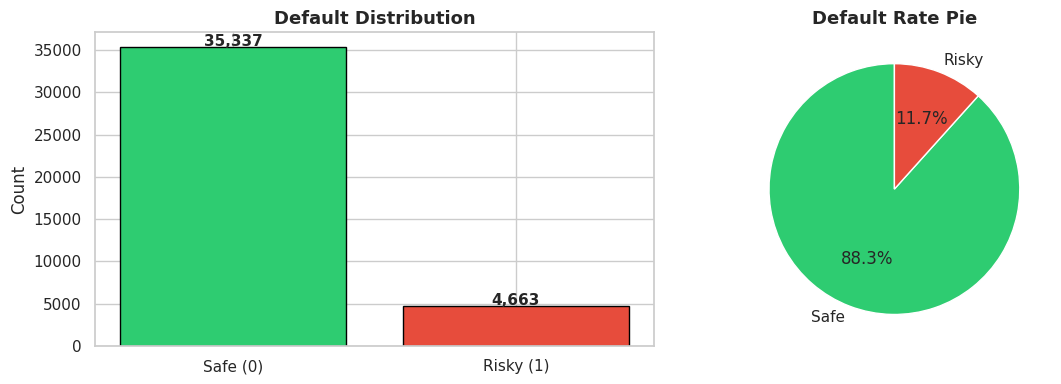

Default Rate: 11.66%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Default'].value_counts()
bars = axes[0].bar(['Safe (0)', 'Risky (1)'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Default Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=['Safe', 'Risky'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Default Rate Pie', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('default_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Default Rate: {df['Default'].mean()*100:.2f}%")

### 4.2 Numerical Feature Distributions by Default Status

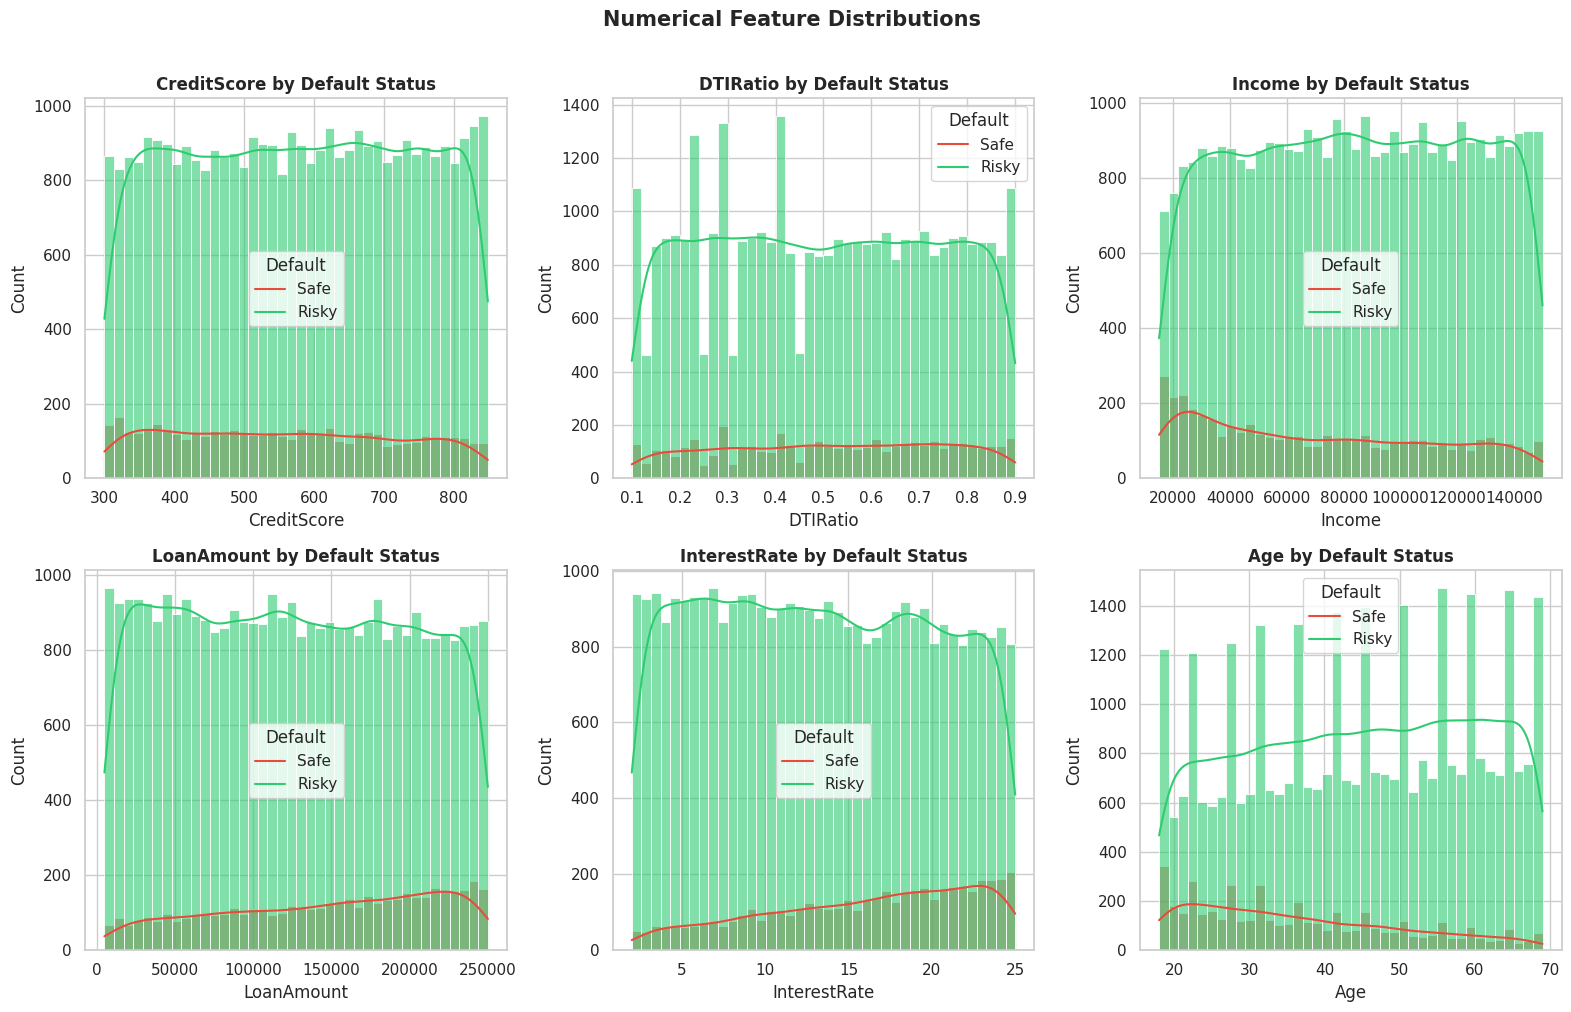

In [9]:
num_cols = ['CreditScore', 'DTIRatio', 'Income', 'LoanAmount', 'InterestRate', 'Age']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Default', kde=True, ax=axes[i],
                 palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.6, bins=40)
    axes[i].set_title(f'{col} by Default Status', fontweight='bold')
    axes[i].legend(['Safe', 'Risky'], title='Default')

plt.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('num_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Categorical Feature — Default Rate Analysis

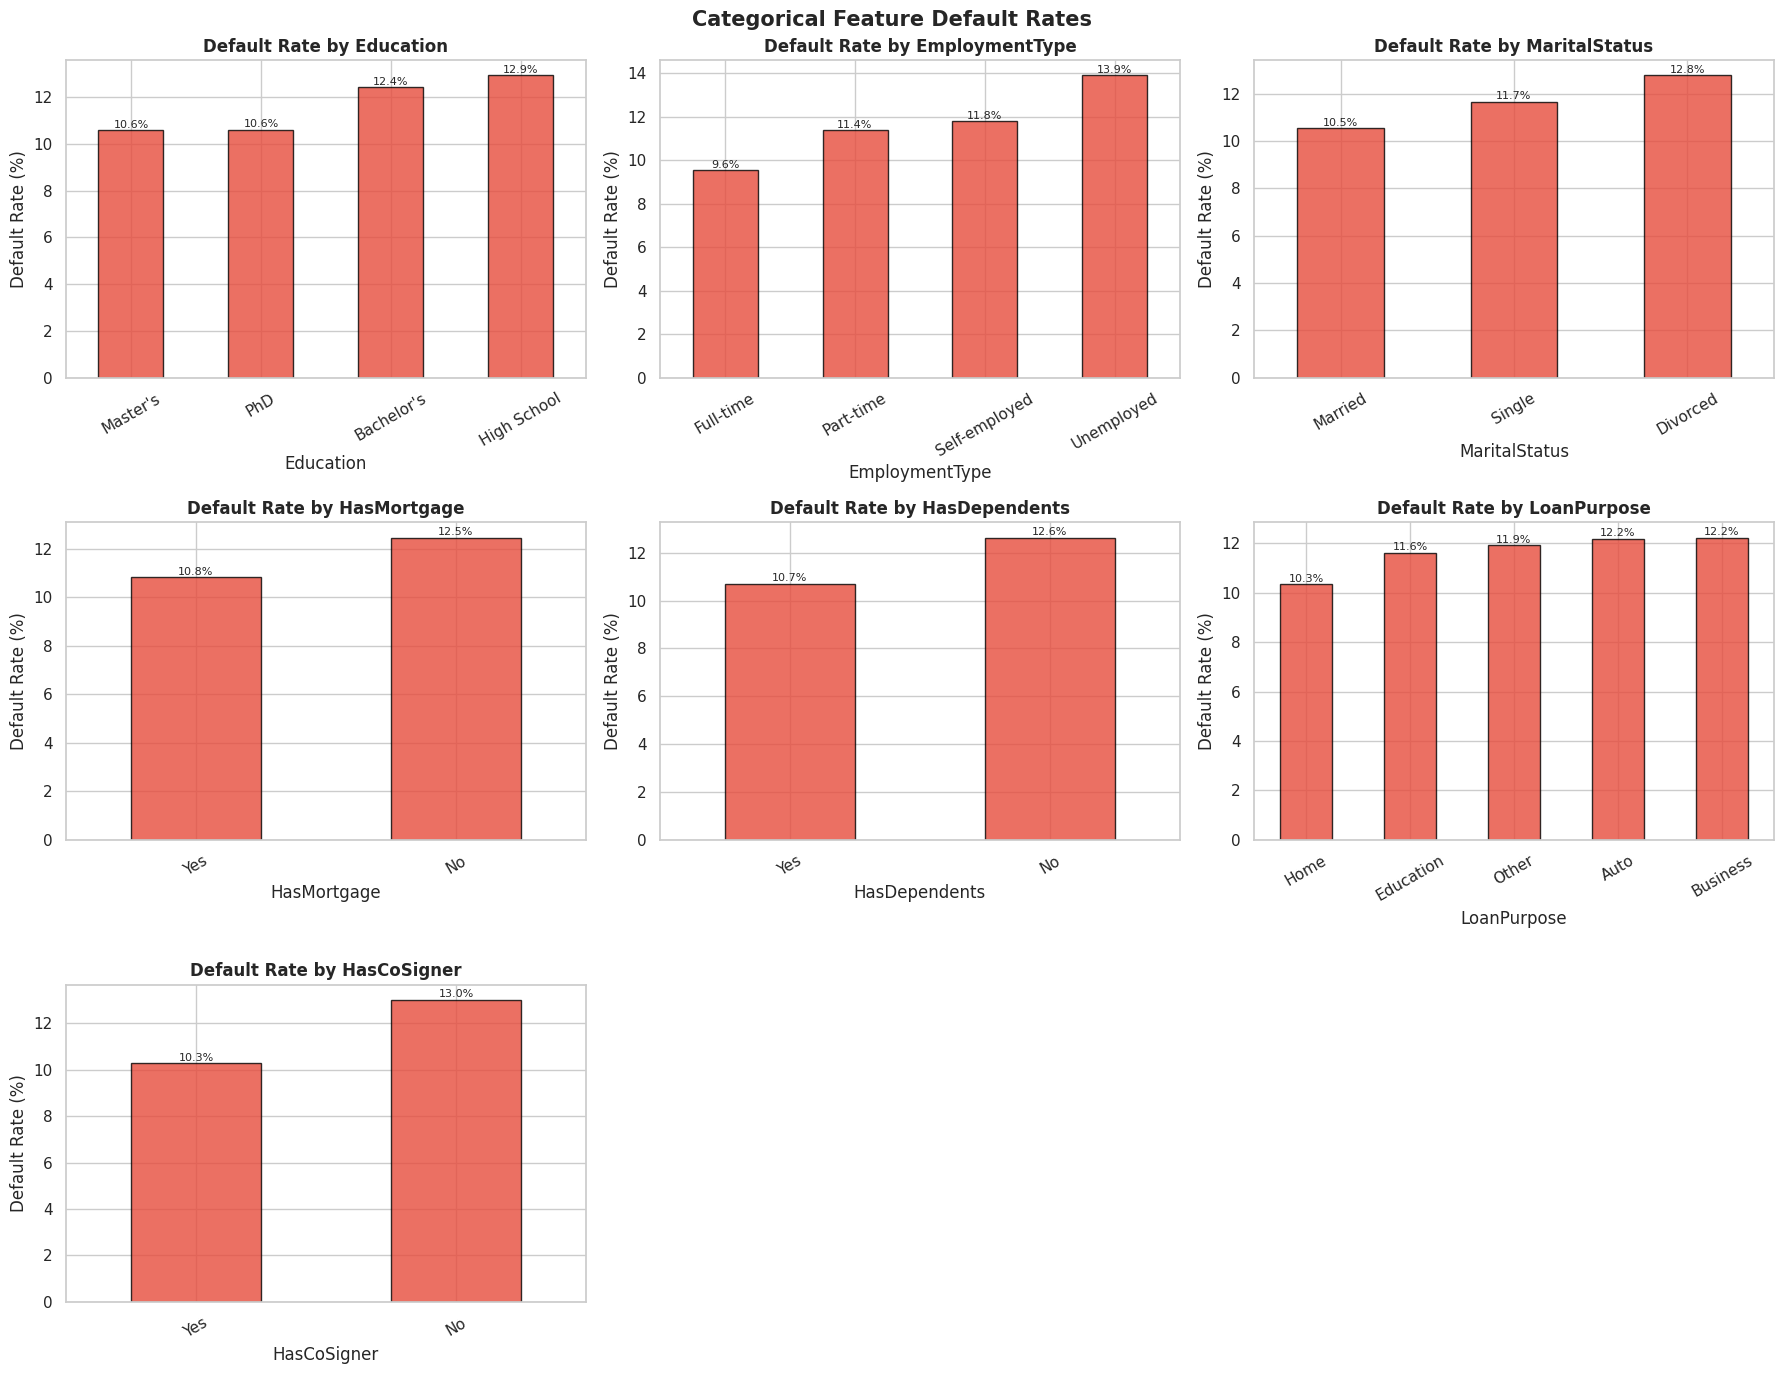

In [10]:
cat_cols = ['Education', 'EmploymentType', 'MaritalStatus',
            'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)['Default'].mean() * 100
    default_rate.sort_values().plot(kind='bar', ax=axes[i],
                                    color='#e74c3c', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=8)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Categorical Feature Default Rates', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('cat_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Boxplots — Income & Loan Amount vs Default

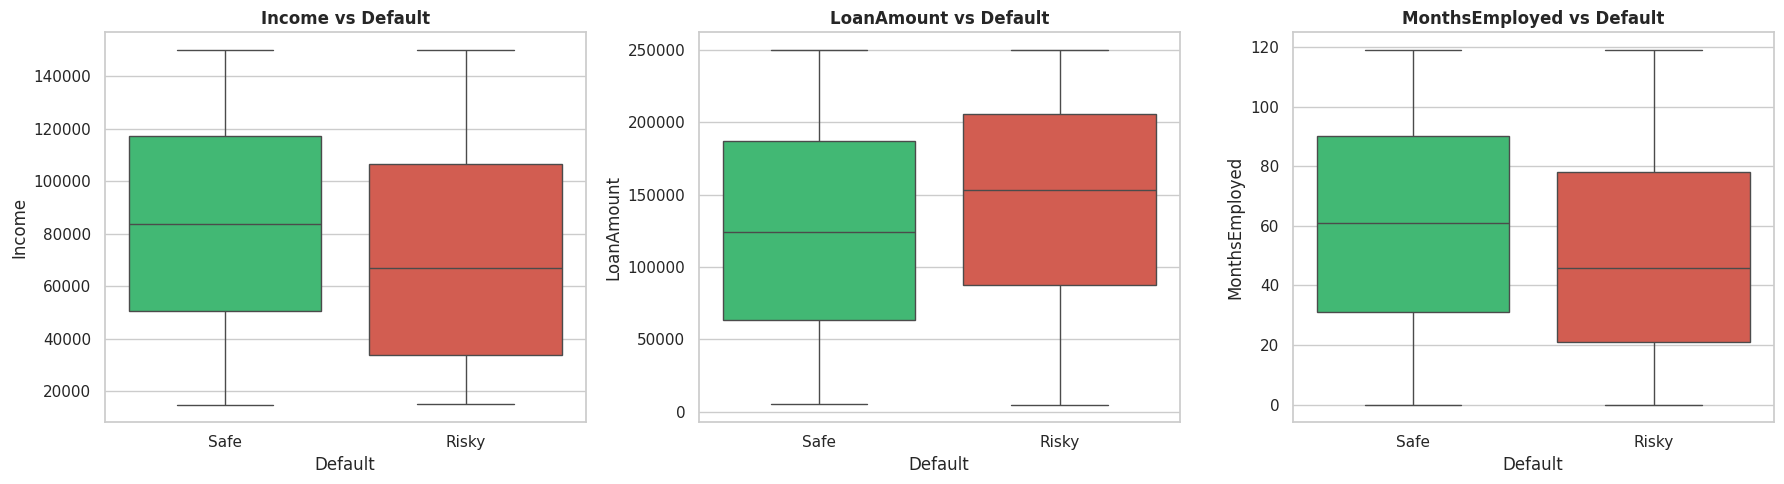

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
boxplot_cols = ['Income', 'LoanAmount', 'MonthsEmployed']

for i, col in enumerate(boxplot_cols):
    sns.boxplot(data=df, x='Default', y=col, hue='Default',
                palette={0: '#2ecc71', 1: '#e74c3c'}, ax=axes[i], legend=False)
    axes[i].set_title(f'{col} vs Default', fontweight='bold')
    axes[i].set_xticklabels(['Safe', 'Risky'])

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Correlation Heatmap

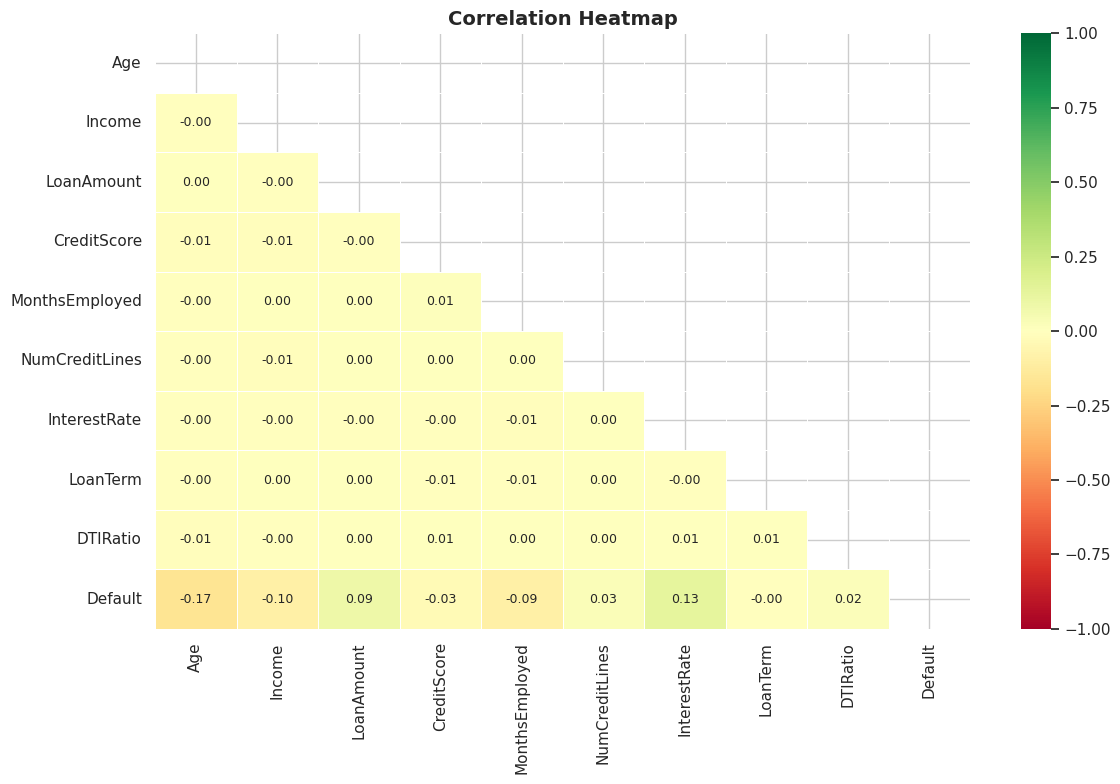

In [12]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number').drop(columns=['LoanID'], errors='ignore')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Key EDA Findings Summary

In [13]:
print('=' * 60)
print('KEY EDA FINDINGS')
print('=' * 60)
print(f"\n1. Default Rate : {df['Default'].mean()*100:.2f}% — highly imbalanced → need SMOTE")
print('\n2. Avg Credit Score by Default:')
print(df.groupby('Default')['CreditScore'].mean().rename({0:'Safe',1:'Risky'}).round(1))
print('\n3. Avg DTI Ratio by Default:')
print(df.groupby('Default')['DTIRatio'].mean().rename({0:'Safe',1:'Risky'}).round(4))
print('\n4. Avg Income by Default:')
print(df.groupby('Default')['Income'].mean().rename({0:'Safe',1:'Risky'}).round(0))
print('\n5. Avg Interest Rate by Default:')
print(df.groupby('Default')['InterestRate'].mean().rename({0:'Safe',1:'Risky'}).round(2))
print('\n6. Top Correlated Features with Default:')
print(numeric_df.corr()['Default'].drop('Default').abs().sort_values(ascending=False).head(6).round(4))

KEY EDA FINDINGS

1. Default Rate : 11.66% — highly imbalanced → need SMOTE

2. Avg Credit Score by Default:
Default
Safe     576.8
Risky    559.7
Name: CreditScore, dtype: float64

3. Avg DTI Ratio by Default:
Default
Safe     0.4985
Risky    0.5138
Name: DTIRatio, dtype: float64

4. Avg Income by Default:
Default
Safe     83651.0
Risky    71992.0
Name: Income, dtype: float64

5. Avg Interest Rate by Default:
Default
Safe     13.25
Risky    15.88
Name: InterestRate, dtype: float64

6. Top Correlated Features with Default:
Age               0.1677
InterestRate      0.1272
Income            0.0959
MonthsEmployed    0.0948
LoanAmount        0.0860
CreditScore       0.0344
Name: Default, dtype: float64


## ⚙️ 5. Data Preprocessing & SMOTE

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pickle

df2 = df.copy()
df2.drop('LoanID', axis=1, inplace=True)

cat_cols = ['Education', 'EmploymentType', 'MaritalStatus',
            'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

# Store encoders for Streamlit
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])
    encoders[col] = le

X = df2.drop('Default', axis=1)
y = df2['Default']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns.tolist()

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

print('Class Distribution:')
print(f'  Before SMOTE: {y.value_counts().to_dict()}')
print(f'  After  SMOTE: {dict(zip(*np.unique(y_res, return_counts=True)))}')

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Class Distribution:
  Before SMOTE: {0: 35337, 1: 4663}
  After  SMOTE: {np.int64(0): np.int64(35337), np.int64(1): np.int64(35337)}

Train size: 56539 | Test size: 14135


## 🤖 6. Model Training & Evaluation

### 6.1 Logistic Regression

=== Logistic Regression Results ===
              precision    recall  f1-score   support

        Safe       0.70      0.68      0.69      7068
       Risky       0.69      0.70      0.69      7067

    accuracy                           0.69     14135
   macro avg       0.69      0.69      0.69     14135
weighted avg       0.69      0.69      0.69     14135

AUC-ROC: 0.7577


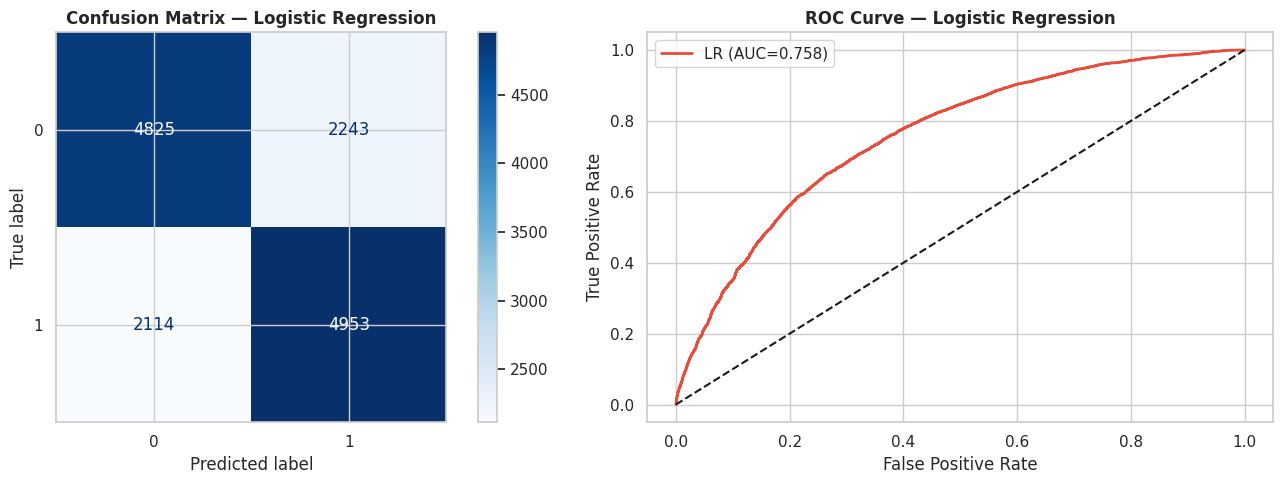

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, roc_curve

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('=== Logistic Regression Results ===')
print(classification_report(y_test, y_pred_lr, target_names=['Safe', 'Risky']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'LR (AUC={roc_auc_score(y_test,y_prob_lr):.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('lr_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Random Forest (Primary Model)

=== Random Forest Results ===
              precision    recall  f1-score   support

        Safe       0.93      0.97      0.95      7068
       Risky       0.97      0.93      0.95      7067

    accuracy                           0.95     14135
   macro avg       0.95      0.95      0.95     14135
weighted avg       0.95      0.95      0.95     14135

AUC-ROC: 0.9876


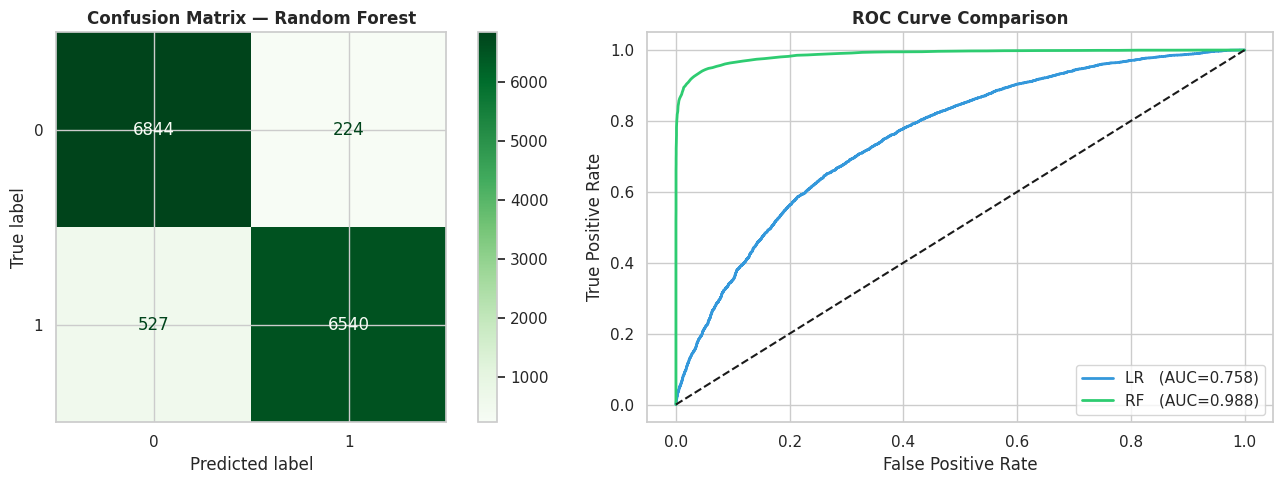

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest Results ===')
print(classification_report(y_test, y_pred_rf, target_names=['Safe', 'Risky']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Greens', ax=axes[0])
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr_lr, tpr_lr, color='#3498db', lw=2, label=f'LR   (AUC={roc_auc_score(y_test,y_prob_lr):.3f})')
axes[1].plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2, label=f'RF   (AUC={roc_auc_score(y_test,y_prob_rf):.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('rf_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Feature Importance

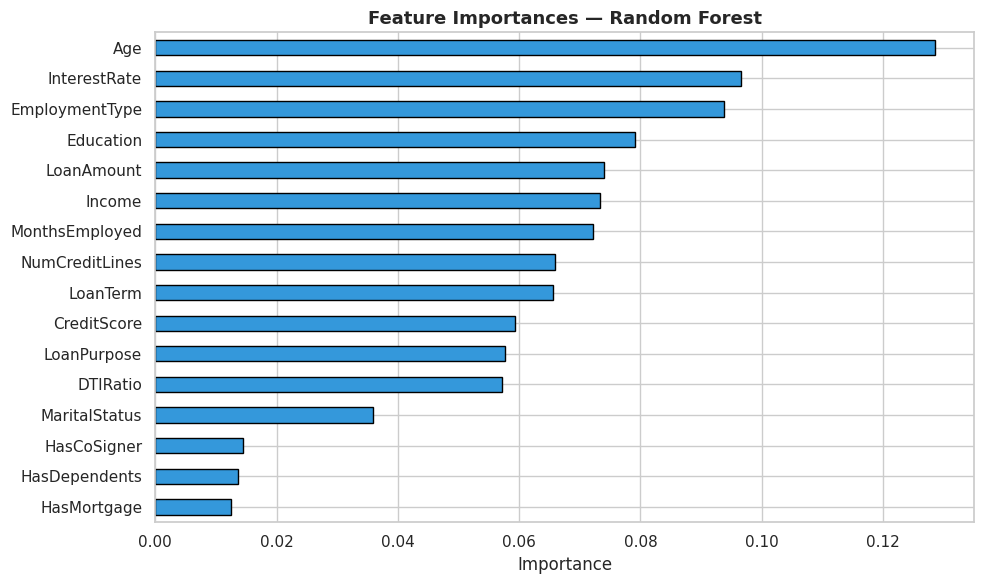

Age               0.1286
InterestRate      0.0966
EmploymentType    0.0937
Education         0.0791
LoanAmount        0.0739
Income            0.0734
MonthsEmployed    0.0722
NumCreditLines    0.0659
LoanTerm          0.0656
CreditScore       0.0594
LoanPurpose       0.0577
DTIRatio          0.0572
MaritalStatus     0.0360
HasCoSigner       0.0145
HasDependents     0.0137
HasMortgage       0.0125
dtype: float64


In [17]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(importances.sort_values(ascending=False).round(4))

## 🔵 7. KMeans Customer Segmentation

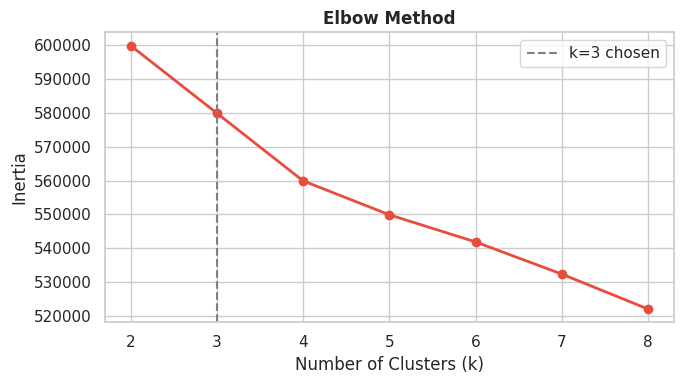

In [18]:
from sklearn.cluster import KMeans

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'o-', color='#e74c3c', lw=2)
plt.axvline(x=3, color='gray', linestyle='--', label='k=3 chosen')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()

=== Cluster Summary ===
         CreditScore  DTIRatio     Income  InterestRate  Default
Cluster                                                         
0            574.331     0.499  82675.046        13.538    0.122
1            574.631     0.500  81978.457        13.548    0.125
2            575.489     0.503  82538.508        13.606    0.095

Risk Segment Distribution:
RiskSegment
High Risk      20026
Low Risk       10052
Medium Risk     9922
Name: count, dtype: int64


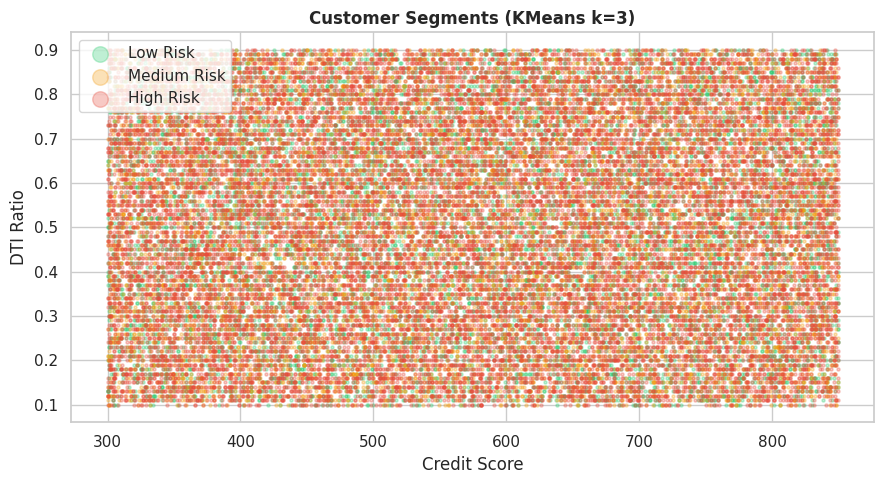

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df2['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df2.groupby('Cluster')[
    ['CreditScore', 'DTIRatio', 'Income', 'InterestRate', 'Default']].mean().round(3)

print('=== Cluster Summary ===')
print(cluster_summary)

# Risk labels based on Default mean
risk_map = cluster_summary['Default'].rank().astype(int).to_dict()
label_map = {k: ['Low Risk', 'Medium Risk', 'High Risk'][v-1] for k, v in risk_map.items()}
df2['RiskSegment'] = df2['Cluster'].map(label_map)

print('\nRisk Segment Distribution:')
print(df2['RiskSegment'].value_counts())

# Scatter plot
plt.figure(figsize=(9, 5))
colors = {'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}
for seg, color in colors.items():
    subset = df2[df2['RiskSegment'] == seg]
    plt.scatter(subset['CreditScore'], subset['DTIRatio'],
                label=seg, alpha=0.3, s=5, color=color)
plt.xlabel('Credit Score')
plt.ylabel('DTI Ratio')
plt.title('Customer Segments (KMeans k=3)', fontweight='bold')
plt.legend(markerscale=5)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 📐 8. TOPSIS Multi-Criteria Risk Scoring

=== Top 10 Riskiest Customers (lowest TOPSIS score) ===
       CreditScore  DTIRatio  Income  InterestRate  Default  RiskSegment  \
31993          310      0.86   24677         24.73        0     Low Risk   
15287          356      0.90   17607         23.17        1    High Risk   
21729          313      0.88   16974         22.62        1     Low Risk   
34395          372      0.87   22107         24.14        1    High Risk   
16152          400      0.87   17308         24.80        0     Low Risk   
4602           390      0.85   17873         24.59        1    High Risk   
1181           338      0.84   20183         23.23        0  Medium Risk   
19643          367      0.89   26051         23.65        0    High Risk   
23527          353      0.82   25099         24.72        0  Medium Risk   
20917          331      0.79   16624         24.53        0    High Risk   

       TOPSIS_Score  
31993        0.0475  
15287        0.0562  
21729        0.0593  
34395        0.0595

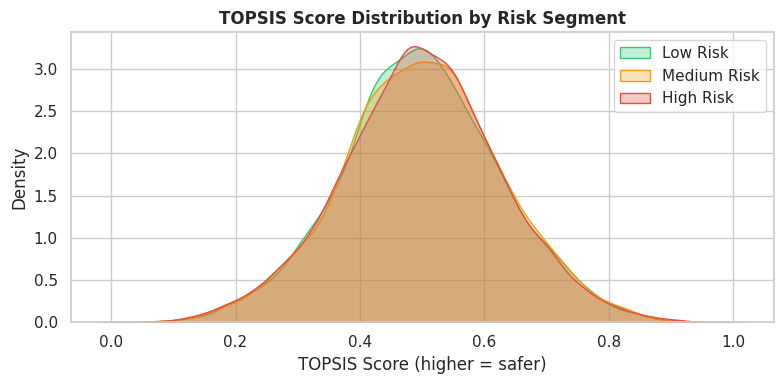

In [20]:
topsis_features = ['CreditScore', 'DTIRatio', 'InterestRate', 'Income']
matrix = df2[topsis_features].values.astype(float)

# Normalize
norm = matrix / np.sqrt((matrix**2).sum(axis=0))

# Equal weights
weights = np.array([0.25, 0.25, 0.25, 0.25])
weighted = norm * weights

# Benefit criteria: CreditScore & Income (higher=better) → True
# Cost criteria   : DTIRatio & InterestRate (lower=better) → False
benefit = [True, False, False, True]

ideal_best  = np.where(benefit, weighted.max(0), weighted.min(0))
ideal_worst = np.where(benefit, weighted.min(0), weighted.max(0))

d_best  = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
d_worst = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

df2['TOPSIS_Score'] = d_worst / (d_best + d_worst)  # 1 = safest, 0 = riskiest

print('=== Top 10 Riskiest Customers (lowest TOPSIS score) ===')
print(df2.sort_values('TOPSIS_Score')[
    ['CreditScore', 'DTIRatio', 'Income', 'InterestRate', 'Default', 'RiskSegment', 'TOPSIS_Score']]
    .head(10).round(4))

plt.figure(figsize=(8, 4))
for seg, color in colors.items():
    subset = df2[df2['RiskSegment'] == seg]['TOPSIS_Score']
    sns.kdeplot(subset, label=seg, color=color, fill=True, alpha=0.3)
plt.title('TOPSIS Score Distribution by Risk Segment', fontweight='bold')
plt.xlabel('TOPSIS Score (higher = safer)')
plt.legend()
plt.tight_layout()
plt.savefig('topsis_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 9. Save Models & Artifacts for Streamlit Deployment

In [21]:
import pickle, os

# Save Random Forest model (best performer)
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save KMeans
with open('kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save label_map for cluster→risk mapping
with open('label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Save encoders
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

saved = [f for f in os.listdir('.') if f.endswith('.pkl')]
print('✅ Saved artifacts:', saved)
print('\n📦 Upload these .pkl files + app.py + requirements.txt to your GitHub repo.')
print('🚀 Then deploy on Streamlit Cloud: https://share.streamlit.io')

✅ Saved artifacts: ['kmeans.pkl', 'encoders.pkl', 'feature_names.pkl', 'scaler.pkl', 'model.pkl', 'label_map.pkl']

📦 Upload these .pkl files + app.py + requirements.txt to your GitHub repo.
🚀 Then deploy on Streamlit Cloud: https://share.streamlit.io


## ✅ 10. Deployment Checklist

| File | Purpose |
|------|---------|
|  | Raw dataset |
|  | Trained Random Forest |
|  | StandardScaler |
|  | KMeans clustering model |
|  | Cluster → Risk label mapping |
|  | Feature column order |
|  | Label encoders for categorical cols |
|  | Streamlit dashboard |
|  | Python dependencies |

### 🔗 GitHub → Streamlit Steps
1. Push all files to a **public GitHub repo**
2. Go to [share.streamlit.io](https://share.streamlit.io)
3. Click **New app** → select your repo → set  as main file
4. Click **Deploy** 🎉